# Assignment 1. Point Operations

<span style="color:orange">Ground Rules for the Assignment: </span>

* <span style="color:lightblue"> You can only use basic functions (matrix operations, input/output image functions, plotters). Anything else, you need to code from scratch (histogram functions, inverting gamma functions, color matting, histogram equalization)</span>
* <span style="color:lightblue"> The code needs to be appropiately commented and should be reproducible; if we cannot re-generate your figures from your code, we will deduct points.</span>
* <span style="color:lightblue">The notebook report should be detailed and include partial and final solutions for each exercise. We grade solely the report; code without report will not be graded, so we encourage that you invest some time on it</span>
* <span style="color:lightblue">Interactive plots are welcome but most important results should be static and generated beforehand</span>
* <span style="color:lightblue">__Remember to remove all plots from the "coding" sections.__ Only the Report should output plots and/or images.</span>


<span style="color:orange">Submission Details</span>

Simply submit this Jupyter Notebook with the report inlined as described below. The notebook should be executed before submission. Name the file as 
```surname1_name1_surname2_name2_assignment1.ipynb```



# Point Operations

Point operations are the simplest kind of image processing transforms. They modify pixel values independently of their location within the image or neighboring values. They are used for simple contrast and brightness enhancements, color adjustments, matting and compression, among other things. In this assignment, we will be learning some of the most common point operators for color images. Remember to use matrix operations whenever possible to obtain efficient code.

In [2]:
# Loading Libraries you will need for the assignment.- Install them in your environment if you haven't done so yet
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy as sp

## 1.1. Tone mapping & Linearization [2 points]

RAW/HDR images (either real or synthetic) usually have a much larger dynamic range than the capabilities
of most displaying devices. We use tone mapping to adapt pixel intensities to the limits of the device that will
display them, maximizing perceived quality. Tone mapping algorithms are designed to adjust the contrast
and brightness of HDR images so that detail in highlights and shadows is preserved when displayed in LDR.

**Gamma Correction.** Display devices like CRTs, LCDs or OLED devices cannot, or are not designed to,
achieve a linear conversion from voltage or intensity to light emitted. In practice, this means that doubling
the value of a pixel would not result in double the light being emitted. In order to solve this issue, each pixel
value is mapped to an exponential function of the type $f(x) = x^\gamma$ , with an encoding gamma of typical value
$\frac{1}{2.2}$. This type of tone mapping is called gamma correction.

**Linearization.** The final product of any digital camera pipeline is a compressed non-linear image, normally
in JPEG format, where tone mapping has already been applied. However, this means intensities have been
mapped with an exponential function. Using linear color for image processing is important because it ensures
that the mathematical operations performed on the image data are consistent with the physics of light and
the way that images are captured and displayed, as light transport is indeed linear.

### _Task_
Implement code to load the ```Ferrari.JPEG``` image into a matrix and invert the function
above to linearize the image back. Assume that the value used for encoding the image was $\gamma = \frac{1}{2.2}$. You can
use ```Image``` to load your images. Try applying other per-pixel functions to
increase brightness (linear multiplications) and contrast enhancement (exponential functions) and showcase
your creations.

In [7]:
# Use np.clip() to ensure that every output is valid in [0,1]
def load_image(path):
    img = Image.open(path).convert("RGB")
    return np.asarray(img, dtype=float) / 255.0

# Decoding the img from nonlinear to linear
def linearize_gamma(img, gamma_encode):
    return np.clip(img ** (1.0 /gamma_encode), 0.0, 1.0)

def gamma_encode_for_display(img, gamma_encode):
    return np.clip(np.clip(img, 0.0, 1.0) ** gamma_encode, 0.0, 1.0)


def increase_brightness(linear_img, brightness):
    return np.clip(linear_img * brightness, 0.0, 1.0)


def enhance_contrast_power(linear_img, alpha):
    return np.clip(np.clip(linear_img, 0.0, 1.0) ** alpha, 0.0, 1.0)


In [19]:
img = load_image("ferrari.JPG")
gamma_encode = 1/ 2.2
brightness=11.2406010613
alpha = 0.6010613
# Decoding
img0 = linearize_gamma(img, gamma_encode)

# Brightness
img1 = increase_brightness(img0, brightness)

# Contrast
img2 = enhance_contrast_power(img0, alpha)

# Display
img0_disp = gamma_encode_for_display(img0, gamma_encode)
img1_disp = gamma_encode_for_display(img1, gamma_encode)
img2_disp = gamma_encode_for_display(img2, gamma_encode)

# Store outputs
output = {
    "input": img,
    "linear": img0_disp,
    "brightness": img1_disp,
    "contrast": img2_disp,
}

###  <span style="color:orange"> _Report_ </span>
<span style="color:orange"> _Report your results below. Include the linerized image, and experiments with contrast and brightness enhancements. Please inline the resulting images with your text explaining the approach (e.g. as figures) so that the report is cohesive._ </span>

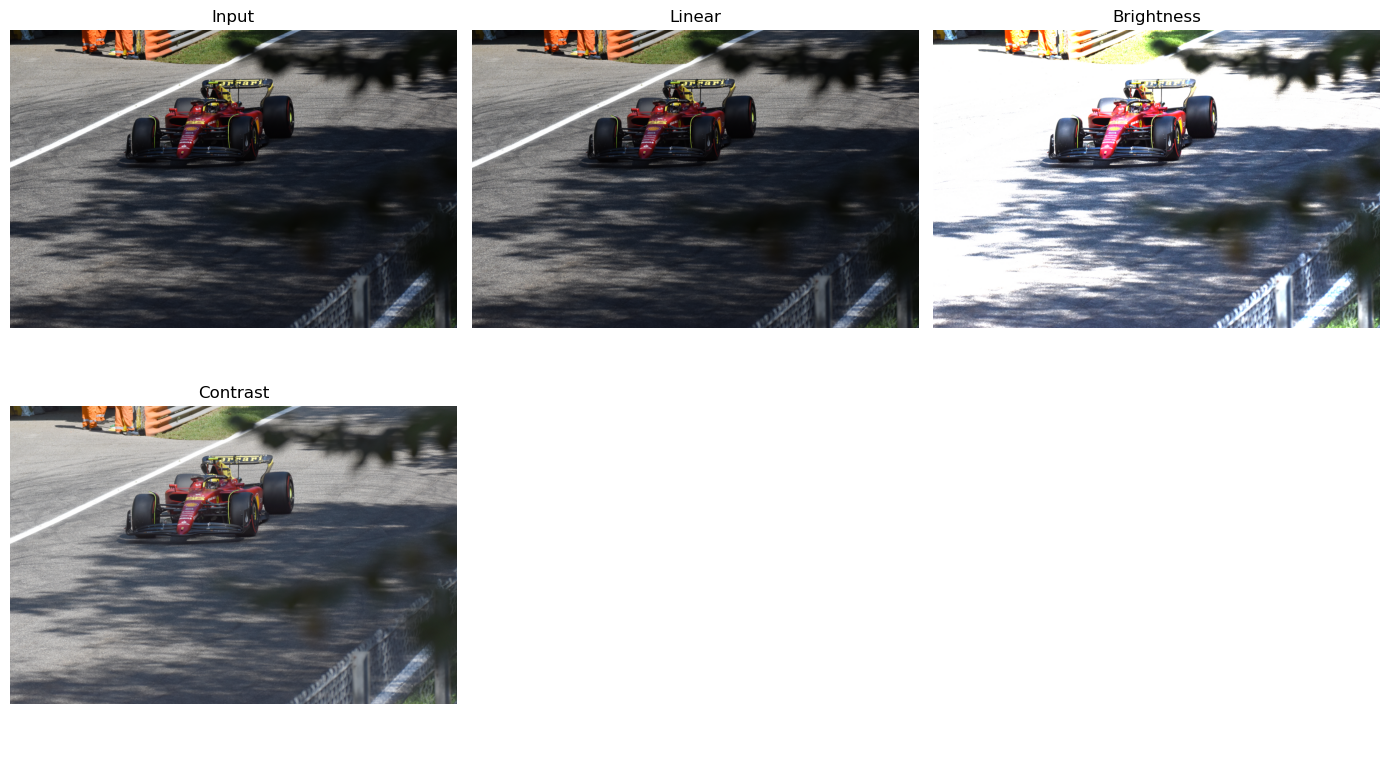

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

titles = [
    "Input",
    "Linear",
    "Brightness",
    "Contrast"
]

imgs = [
    output["input"],
    output["linear"],
    output["brightness"],
    output["contrast"]
]

for ax, img, t in zip(axes, imgs, titles):
    ax.imshow(img)
    ax.set_title(t)
    ax.axis("off")

for ax in axes[len(imgs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Because of $$V_{encoded} = V_{linear}^{1/\gamma}$$  For codes above, I use $$V_{linear} = V_{encoded}^{\gamma}$$ to get the linear output.   
The brightness funtion achieves a linear conversion: $$y = brightness * x$$, the bigger brightness is, the brighter the image is.  
Contrast: $$y = x^\alpha$$ When $\alpha<1$, the contrast appears lower visually and the image becomes grayer and flatter.  
When $\alpha>1$ it will have the opposite effect.

## 1.2. Color correction [4 points]

### _Task_
Implement both simple white balance methods to correct color in the example image ```white_balance_input.jpg```.
Example results are shown below. Note that your results may be different. The difference may come, for example, from choosing a slightly different pixel for color correction. When choosing the pixel try to choose
one that is gray, not too bright, and not too dark.
For the report, please experiment with doing the transformations directly on the values of the input image and the intensities, i.e., after applying inverse gamma correction.

![image.png](attachment:image.png)

In [ ]:
# Gray world
def gray_world_balance_numpy(image_path):
    img = Image.open(image_path)
    img_array = np.array(img, dtype=np.float64)

    avg_rgb = np.mean(img_array, axis=(0, 1))
    
    avg_gray = np.mean(avg_rgb)

    gains = avg_gray / avg_rgb

    result = img_array * gains

    result = np.clip(result, 0, 255).astype(np.uint8)

    return Image.fromarray(result)

# Pixel Based Correction, select the brightest 1% of pixels in the entire image as "reference white".
def pixel_based(image_path, percentile=99):

    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img, dtype=np.float64)

    brightness = np.mean(img_array, axis=2)

    threshold = np.percentile(brightness, percentile)

    # Find the brightest pixels.
    white_mask = brightness >= threshold

    white_ref_rgb = np.mean(img_array[white_mask], axis=0)
    
    # Calculate gain
    target_val = 255.0
    gains = target_val / white_ref_rgb

    result = img_array * gains
    result = np.clip(result, 0, 255).astype(np.uint8)

    return Image.fromarray(result)



In [31]:
img_original = Image.open("white_balance_input.jpg").convert("RGB")
img_gray_world = gray_world_balance_numpy("white_balance_input.jpg")
img_pixel_based = pixel_based("white_balance_input.jpg")



###  <span style="color:orange"> _Report_ </span>
<span style="color:orange">_Report your results below. Include experiments with doing the transformations directly on the values of the input image
and the intensities, i.e., after applying inverse gamma correction. Please inline the resulting images with your text explaining the approach (e.g. as figures) so that the report is cohesive._</span>


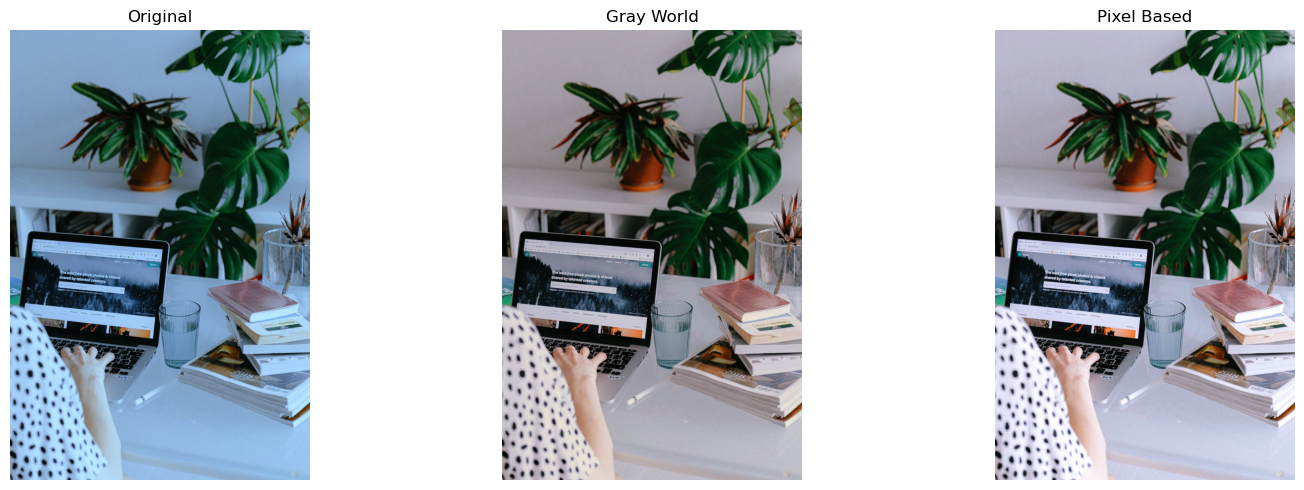

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
images = [img_original, img_gray_world, img_pixel_based]
titles = ["Original", "Gray World", "Pixel Based"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

I implemented two white-balance methods:

Gray World:  The average scene color should be neutral gray.  
I compute channel-wise means $\mu_R,\mu_G,\mu_B$, then apply gains so all channels move toward the same average gray value.

Pixel Based (White Patch)  
I select the brightest pixels (top 1% by brightness) as reference white, compute their average RGB, and scale each channel so this reference approaches ([255,255,255]).

## 1.3 Histograms [2 points]

Histograms show the frequency of occurrence of different pixel intensity levels in the image. We can use
them to obtain exposure information (assessing whether an image has captured a sufficient amount of light).
Color histograms can also be used to manipulate images. For instance, if an image has too much blue, you
can adjust the histogram to reduce the amount of blue, by shifting the blue values towards the center of the
histogram, which will reduce its intensity in the image.

### _Task_

Implement a histogram plotter using basic operations (your OWN implementation) and
show the color histogram of the provided image. You will need to obtain the cumulative distribution of pixel values for each color channel and map them into a certain number of bins to display them.

In [ ]:
# Define your functions here .- you can include comments in your code explaining the steps of your algorithm

In [ ]:
# Execute your code here

###  <span style="color:orange"> _Report_ </span>
<span style="color:orange">_Report your results below. Include experiments with different images, and compute different histograms before and after performing some of the point operations implemented in 1.1. Please inline the resulting images with your text explaining the approach (e.g. as figures) so that the report is cohesive._</span>

In [ ]:
# Plotting code here

_... Add your text here._

## 1.4 Histogram Equalization [7 points + 5 Bonus]

Another way of using histograms to manipulate images is through histogram equalization. By redistributing
pixel intensities across the image based on its histogram, we can improve its contrast.
There are several ways of performing histogram equalization:

* **Global** methods consist on calculating the cumulative distribution function of the histogram, normalizing it and then mapping each pixel in the image to their new normalized intensity.

* **Local** methods work on pre-defined windows across the image (think of cropped squares of a fixed
size), where a histogram is computed for each window and normalized using the previous method
independently.
* **Locally adaptive** methods use a moving window across the image instead of fixed-place boxes. Each
pixel value is then equalized according to the histogram of its small surrounding window, repeating
the task for every pixel in the image.

![image.png](attachment:image.png)

### _Task_

Implement global and local histogram equalization methods using basic functions (your
OWN implementation) and show the results of applying each to the same image. For local methods, you should try with different window sizes. Interpret these results and argue benefits and problems of each.

__Important Note.__ Running any kind of histogram equalization on each color channel separately will probably alter the colors in the image. Instead, you may use a stock Pillow/numpy/scipy function to convert the image to HSV or HSL color spaces and work only on the value/lightness axis. This will only alter brightness in the image and preserve color.

<span style="color:red">Bonus.</span> Implement a locally adaptive method based on the previous two.

![image.png](attachment:image.png)

In [ ]:
# Define your functions here.- you can include comments in your code explaining the steps of your algorithm

In [ ]:
# Execute your code here

###  <span style="color:orange"> _Report_ </span>
<span style="color:orange">_Report your results below. Include experiments with different window sizes, and compare between all methods on the same images. Show their impact on their histograms and interpret it as well. Please inline the resulting images with your text explaining the approach (e.g. as figures) so that the report is cohesive._</span>

In [ ]:
# Plotting code here

_... Add your text here._

## 1.5 Matting [5 points]

Another basic operation in image processing is matting. In its simplest form, image pixels are filtered using
a threshold which results in a mask or matte. This mask is used to isolate a specific object in the image, so
that we can either place it in another image or simply change its background. Although recently, semantic
classification of pixels through machine learning or deep learning methods have obsoleted classic techniques
such as chroma keys (selecting matte masks according to color backgrounds), it is still a powerful and cheap
tool for matting.

### _Task_

Implement a function to filter (threshold) the provided image based on the color background to obtain a mask, which will then be used to replace this background with a different image of your choice.

![image.png](attachment:image.png)

In [ ]:
# Define your functions here .- you can include comments in your code explaining the steps of your algorithm

In [ ]:
# Execute your code here

###  <span style="color:orange"> _Report_ </span>
<span style="color:orange">Report your results below. Include tests with different foreground and background images. Please inline the resulting images with your text explaining the approach (e.g. as figures) so that the report is cohesive. </span>

In [ ]:
# Plotting code here

_... Add your text here._